In [1]:
%load_ext autoreload
%autoreload 2

# Importing the modules

    
import config_2Dcoupling_V3 as cfg              # config = physical & simulation parameters 
from solver_Hcurl_2D_V3 import *                # solver = mesh build, physics import and FEM method + pmls initialization
import Post_Process_V3_Run_n_Save as pp_run     # post process run and save = run scan function and save data in H5 files
import Post_Process_V3_Load_n_Plot as pp_plot   # post process load and plot = recover the sim data from H5 files and plot graphs "instantly"


In [2]:
solver = LHCouplingSolver_2DHcurl_1DH1(cfg.__dict__)

In [3]:
mesh_save_dir = Path("/Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V3_(radial&torodial_pmls)/Meshes")
mesh_save_dir.mkdir(parents=True, exist_ok=True)

figure_save_dir = Path("/Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V3_(radial&torodial_pmls)/Figures")
figure_save_dir.mkdir(parents=True, exist_ok=True)


solver.build_physics_Stix_B_field(lambda x, z: pp_run.create_density_profile(x, z, solver))
mesh = solver.build_mesh_with_PMLs(mesh_save_dir)
# print('num_vertices = ', mesh.nv)

GF_E_field, _ = solver.solve_helmholtz_Hcurl_2D_pml(mesh, cfg)

ne = 3e+18, type(ne) = <class 'float'>
#DoFs = 20945 (= number of mesh points).
--- Solving the 3D vector linear system ---
--- System solved ---


In [4]:
# Create the Run_XXX_XXX file in Simulation_Results folder
# run_folder = /Simulation_Results/Run_XXX
run_folder_path = pp_run.setup_output_directory("Simulation_Results", save_data=True)

# Total Run_XXX folder path to Remi's shared zone (cea intra) 
run_folder_tot_path = '/Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V3_(radial&torodial_pmls)/' + run_folder_path
print(f'sim_target_folder: {run_folder_tot_path}')



[SYSTEM] Output directory created: Simulation_Results/Run_20260522_105447
sim_target_folder: /Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V2_(radial_pml_only)/Simulation_Results/Run_20260522_105447


--- Extracting 2D Wave Map ---
params recover in run_2D_wave_map
--- 2D Map saved to /Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V2_(radial_pml_only)/Simulation_Results/Run_20260522_105447/Wave_Map_2D.h5 ---
--- Plotting 2D Map from /Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V2_(radial_pml_only)/Simulation_Results/Run_20260522_105447/Wave_Map_2D.h5 ---


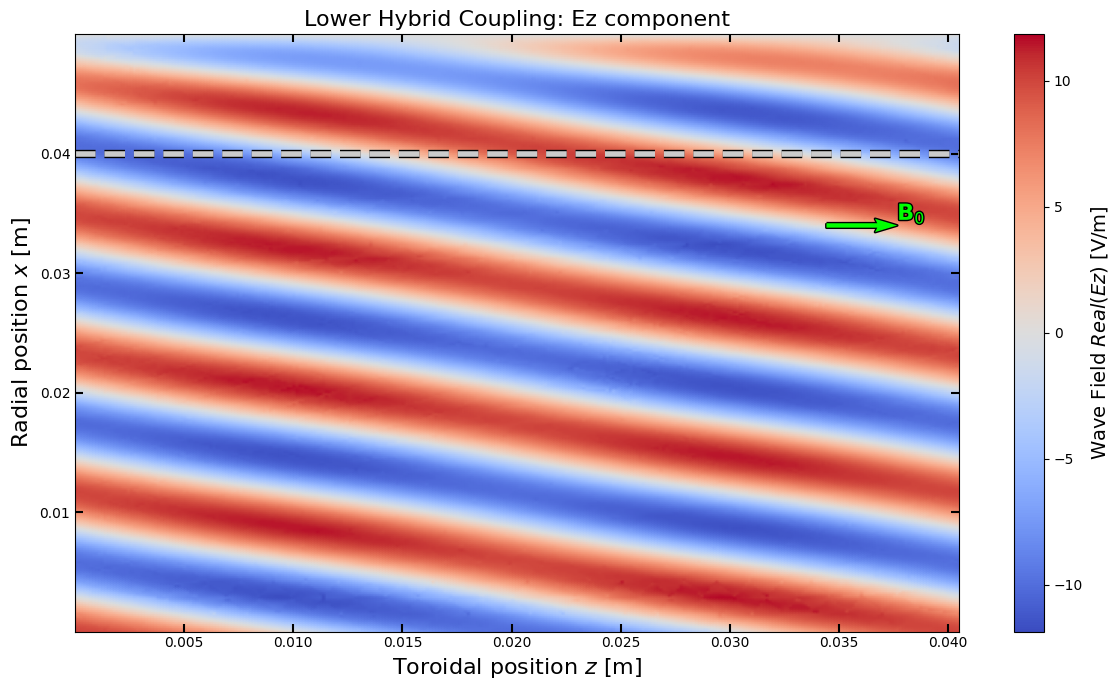

In [5]:
# --- Post-treatment: --- 
# Generate the H5 file for 2D map plot and save it in Run_XXX folder 
E_map2D_h5_filepath = pp_run.run_2D_wave_map(mesh, GF_E_field, cfg, run_folder_tot_path)
# Plot E field 2D map and save it in the same folder: Run_XXX 
pp_plot.plot_2D_wave_map(E_map2D_h5_filepath, run_folder_tot_path, component='Ez', value_type='real', plot_e_vectors=False)

In [6]:
# E_radial_profile_h5_filepath = pp_run.run_1D_radial_profile(mesh, GF_E_field, cfg, run_folder_tot_path)
# pp_plot.plot_1D_radial_benchmark(E_radial_profile_h5_filepath, run_folder_tot_path, component='Ex')
# pp_plot.plot_1D_radial_benchmark(E_radial_profile_h5_filepath, run_folder_tot_path, component='Ey')
# pp_plot.plot_1D_radial_benchmark(E_radial_profile_h5_filepath, run_folder_tot_path, component='Ez')

In [7]:
h5_file_path = pp_run.run_pml_scan_dataset(solver, cfg, run_folder_tot_path)

--- Initiating ULTIMATE 7D Sobol Data Lake: 4096 Simulations ---



Run 1/4096 | S_i:5.8, L:4.4λ, p:2.4, n//:17.16, ne:1.8e+19


#DoFs = 87300 (= number of mesh points).
--- Solving the 3D vector linear system ---
--- System solved ---
  --> FEM Solve Successful | Gamma = 1.13e-03
--- Run ok & data saved correctly ---



Run 2/4096 | S_i:0.6, L:9.2λ, p:1.7, n//:56.61, ne:4.8e+18


#DoFs = 82717 (= number of mesh points).
--- Solving the 3D vector linear system ---
--- System solved ---
  --> FEM Solve Successful | Gamma = 1.53e-02
--- Run ok & data saved correctly ---



Run 3/4096 | S_i:1.5, L:1.1λ, p:2.8, n//:80.40, ne:1.4e+18


#DoFs = 11498 (= number of mesh points).
--- Solving the 3D vector linear system ---
--- System solved ---
  --> FEM Solve Successful | Gamma = 2.43e-01
--- Run ok & data saved correctly ---



Run 4/4096 | S_i:3.0, L:5.9λ, p:2.1, n//:42.63, ne:6.2e+18


#DoFs = 65398 (= number of mesh points).
--- Solving the 3D vector linear system ---
--- System solved ---

no more timer available (FESpace), reusing last one


#DoFs = 44040 (= number of mesh points).
--- Solving the 3D vector linear system ---
--- System solved ---
  --> FEM Solve Successful | Gamma = 4.78e-02
--- Run ok & data saved correctly ---



Run 899/4096 | S_i:1.4, L:3.8λ, p:2.0, n//:61.53, ne:5.0e+17


#DoFs = 11686 (= number of mesh points).
--- Solving the 3D vector linear system ---
--- System solved ---
  --> FEM Solve Successful | Gamma = 9.65e-01
--- Run ok & data saved correctly ---



Run 900/4096 | S_i:3.1, L:8.6λ, p:2.8, n//:23.63, ne:1.4e+19


#DoFs = 132389 (= number of mesh points).
--- Solving the 3D vector linear system ---
--- System solved ---
  --> FEM Solve Successful | Gamma = 1.88e-03
--- Run ok & data saved correctly ---



Run 901/4096 | S_i:3.7, L:4.8λ, p:2.9, n//:6.88, ne:1.7e+19


#DoFs = 89205 (= number of mesh points).
--- Solving the 3D vector linear system ---
--- System solved ---
  --> FEM Solve Successful | Gamma = 1.97e-03
--- Run ok & data saved correctly ---



Run 902/4096 | S_i:1.7, L:9.0λ, p:2

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from Post_Process_V3_Explore_Data import PMLDataExplorer

explorer_data_file = "/Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V2_(radial_pml_only)/Simulation_Results/Run_20260522_105447/PML_scan_all_param_dataset.h5"

# explorer_data_file = run_folder_tot_path + "/" + h5_file_path
print(explorer_data_file)
explorer = PMLDataExplorer(explorer_data_file)

display(explorer.df.describe())

/Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V2_(radial_pml_only)/Simulation_Results/Run_20260522_105447/PML_scan_all_param_dataset.h5
--- Loading Data Lake from /Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V2_(radial_pml_only)/Simulation_Results/Run_20260522_105447/PML_scan_all_param_dataset.h5 ---
[INFO] Data cleaned. Removed 0 failed simulations. Valid runs available: 4096


,B0,CPU_Time,D_stix,DoFs,Gamma_E,Gamma_S,L_pml_ratio,Lx_pml,P_stix,S_imag,S_real,S_stix,lambda_para,lambda_perp,n_e,n_para,n_perp_minus,n_perp_plus,omega,p_degree
count,4.096000e+03,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4.096000e+03,4096.000000,4096.000000,4096.000000,4.096000e+03,4096.000000
mean,3.700000e+00,1.762327,2.264215,65673.468994,0.099356,0.099356,5.500000,0.005387,-62.313697,3.171178,5.500000,1.063640,0.003600,0.000979,1.074879e+19,50.550000,0.013667,316.545962,2.324779e+10,2.250000
std,8.882869e-16,1.349637,2.630226,48837.046124,0.182475,0.182475,2.598393,0.017679,73.548371,2.567864,2.598393,0.073927,0.006368,0.002983,1.248633e+19,28.553457,0.201681,288.479163,7.630326e-06,0.433066
min,3.700000e+00,0.055529,0.105360,596.000000,0.000104,0.000104,1.001722,0.000000,-293.236797,0.500186,1.001732,1.002961,0.000000,0.000000,5.001703e+17,1.105738,0.000000,0.000000,2.324779e+10,1.500014
25%,3.700000e+00,0.735368,0.333203,27773.750000,0.002500,0.002500,3.251008,0.000808,-92.125619,1.057608,3.251119,1.009365,0.001074,0.000181,1.581795e+18,25.834376,0.001000,104.235413,2.324779e+10,1.874954
50%,3.700000e+00,1.338793,1.053515,50850.500000,0.016309,0.016309,5.499844,0.001794,-28.459190,2.235777,5.500402,1.029611,0.001598,0.000368,5.001297e+18,50.549811,0.001000,219.478394,2.324779e+10,2.249886
75%,3.700000e+00,2.417530,3.330345,90578.750000,0.097925,0.097925,7.749247,0.004217,-8.317266,4.728892,7.749310,1.093605,0.003120,0.000771,1.580997e+19,75.265811,0.001000,446.926909,2.324779e+10,2.624791
max,3.700000e+00,7.870963,10.522453,253173.000000,0.974761,0.974761,9.998041,0.511006,-1.946158,9.992731,9.998526,1.295753,0.070074,0.087074,4.995268e+19,99.994641,6.176043,1497.688309,2.324779e+10,2.999665


[INFO] Applied filter 'Gamma_S < 0.0005'. Points remaining: 244


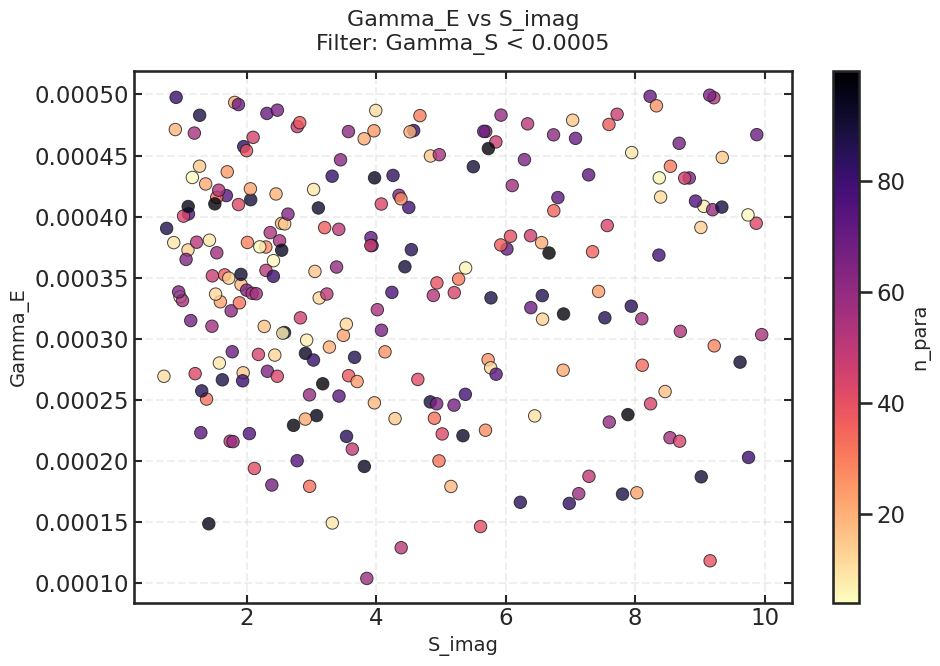

In [11]:
explorer.plot_universal_scatter(
    x_var = 'S_imag', 
    y_var='Gamma_E', 
    color_var='n_para',
    filter_query="Gamma_S < 0.0005"
)

In [12]:
import seaborn as sns 
import pandas as pd
import h5py

#print(df.keys())
with h5py.File(explorer_data_file, 'r') as h5f:
    data_dict = {key: h5f[key][:] for key in h5f.keys()}

df = pd.DataFrame(data_dict)
df = df.query('Gamma_E < 0.99').copy()
 
corr_matrix = df[['Gamma_E', 'S_real', 'S_imag', 'p_degree', 'L_pml_ratio', 'CPU_Time', 'n_para', 'n_e']].corr(method='spearman')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidth=.5)

In [13]:
best_run_df = df.query('Gamma_E < 0.0003')
# sns.pairplot(best_run_df, vars=['Gamma_E', 'S_real', 'S_imag', 'L_pml_ratio', 'n_para', 'n_e'], diag_kind='kde', plot_kws={'alpha':0.6})
# plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Load clean dataset
clean_df = df.query("0 < Gamma_E < 0.90").copy()
clean_df['n_e_log'] = np.log10(clean_df['n_e']) 
features = ['S_imag', 'L_pml_ratio', 'S_real', 'p_degree', 'n_para', 'n_e_log']

X = clean_df[features].values              # X = inputs of the model 
Y = np.log10(clean_df['Gamma_E'].values)   # Y = outputs
 
print(f"Valid runs for training: {len(clean_df)}")

# Standardize Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, train_size=2000, random_state=42)

# Generating the kernel
physics_kernel = C(1.0) * Matern(length_scale=[1.0] * len(features), nu=2.5)
noise_kernel = WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-3, 1.0))
full_kernel = physics_kernel + noise_kernel

# GPR Configuration
gpr = GaussianProcessRegressor(
    kernel=full_kernel, 
    n_restarts_optimizer=10, 
    normalize_y=True, 
    random_state=42
)

print("Training Noise-Adaptive GPR (This may take 1-2 minutes)...")
gpr.fit(X_train, y_train)

# 8. Validation
y_pred_test = gpr.predict(X_test)
r2 = r2_score(y_test, y_pred_test)

print(f"\n[VALIDATION] GPR R^2 Score on unseen data: {r2:.4f}")

Valid runs for training: 4070
Training Noise-Adaptive GPR (This may take 1-2 minutes)...


In [ ]:
if r2 > 0.85:
    print("\n[SUCCESS] The model successfully mapped the physics and ignored the mode-mixing noise.")
    
    # Print the learned length scales
    learned_scales = gpr.kernel_.k1.k2.length_scale
    print("\nLearned Length Scales (Smaller = Higher Physical Impact):")
    for name, scale in zip(features, learned_scales):
        print(f"{name:12}: {scale:.2f}")

In [ ]:
sweep_size = 100000
sampler = qmc.Sobol(d=len(features), scramble=True)
mc_raw = sampler.random(n=sweep_size)
    
bounds = {
        'S_imag': [0.5, 30.0],
        'L_pml_ratio': [4.0, 20.0],
        'p_degree': [1.0, 4.0],
        'S_real': [1.0, 10.0]}

X_mc = np.zeros_like(mc_raw)
for i, key in enumerate(features):
    lb, ub = bounds[key]
    X_mc[:, i] = lb + mc_raw[:, i] * (ub - lb)

X_mc_scaled = scaler.transform(X_mc)
mu_log, sigma_log = gpr.predict(X_mc_scaled, return_std=True)

ucb_log = mu_log + (1.96 * sigma_log) # 1.96*sigma = 95% of confidence
    
# Convert back from log to linear space
UCB_linear = 10**ucb_log

# filter refl coeff
threshold = 1.5e-3
safe_indices = np.where(UCB_linear <= threshold)[0]

if len(safe_indices) == 0:
        print(f"[!] No parameters guarantee Gamma_E < {threshold} under 95% certainty.")
    else:
        safe_points = X_mc[safe_indices]
        safe_df = pd.DataFrame(safe_points, columns=features)
        
        print(f"Found {len(safe_indices)} configurations guaranteeing Gamma_E < {threshold}.")
        print("\n--- ROBUST OPERATING BOUNDARIES ---")
        for col in features:
            val_min = safe_df[col].min()
            val_max = safe_df[col].max()
            # MUST ADD A VARIANCE COMPUTATION !!
            print(f"{col:12} : Range [{val_min:.2f}  to  {val_max:.2f}]")
    print("\n")


In [ ]:
from SALib.sample import saltelli
from SALib.analyze import sobol

print("=== PHASE 3: GLOBAL SENSITIVITY ANALYSIS (SOBOL INDICES) ===")
# 1. Define the Problem for SALib
    problem = {
        'num_vars': len(features),
        'names': features,
        'bounds': [bounds[f] for f in features]
    }
    
    # 2. Generate Saltelli Samples (Required for variance decomposition)
    # 1024 base samples yields 1024 * (2D + 2) = 10,240 evaluations
    X_salib = saltelli.sample(problem, 1024)
    
    # 3. Evaluate samples using our GPR
    X_salib_scaled = scaler.transform(X_salib)
    y_salib_log = gpr.predict(X_salib_scaled) # We analyze the mean prediction
    
    # 4. Compute Sobol Indices
    Si = sobol.analyze(problem, y_salib_log, print_to_console=False)
    
    print("--- VARIANCE DECOMPOSITION RESULTS ---")
    for i, name in enumerate(features):
        S1 = Si['S1'][i]  # First-Order (Main effect of this parameter alone)
        ST = Si['ST'][i]  # Total-Order (Effect including interactions with others)
        print(f"{name:12} | Main Effect (S1): {S1*100:5.1f}% | Total Effect (ST): {ST*100:5.1f}%")
        
    print("\n[CONCLUSION] If S1 is near 0%, the parameter does not independently drive the physics.")
    print("If ST is large but S1 is small, the parameter is highly coupled to another variable.")



In [ ]:
# mesh_conv_h5_filepath = pp_run.run_mesh_convergence(solver, cfg, run_folder_tot_path)

In [ ]:
# pp_plot.plot_mesh_convergence(mesh_conv_h5_filepath, run_folder_tot_path)

In [ ]:
# Pour faire des boucles sur les params de config_dict

cfg.DOMAIN['Lx_plasma'] = 30.
print(cfg.DOMAIN['Lx_plasma'] )

